# Local Convergence

In [47]:
#Modules
import jax.numpy as jnp
import jax.random as jrandom
from jax import vmap, jit, hessian

from abc import ABC

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as tkr

import os

import pickle

from geometry.manifolds.riemannian import RiemannianManifold
from geometry.geodesics.riemannian import JAXOptimization, ScipyOptimization, GEORCE, SparseNewton
from geometry.manifolds.riemannian import nEllipsoid, nSphere, nParaboloid, T2, RiemannianManifold, FisherRaoGeometry, nEuclidean

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [48]:
plt.rcParams.update({'font.size': 25})
cbformat = tkr.ScalarFormatter()   # create the formatter
cbformat.set_powerlimits((-2,2)) 

plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath} \usepackage{amsfonts} \usepackage{multirow} \usepackage{booktabs}')

In [49]:
figure_path = '../figures/riemannian/geodesics/'

In [50]:
if not (os.path.exists(figure_path)):
    os.makedirs(figure_path)

In [51]:
T=100
tol = 1e-4
max_iter = 1000

jax_lr_rate = 0.01

In [52]:
N_sim = 100

def init_fun(z0,zT,T):

    rng_key = jrandom.key(2712)
    
    rng_key, subkey = jrandom.split(rng_key)
    curve = (zT-z0)*jnp.linspace(0.0,1.0,T,endpoint=False,dtype=z0.dtype)[1:].reshape(-1,1)+z0
    eps = jrandom.normal(subkey, shape=(T-1,len(z0)))

    return curve + eps

In [53]:
def compute_estimates(M, Geodesic, z0, zT, base_curve):
    
    new_method = {}
    zt, grad, idx = Geodesic(z0,zT, "for")

    init_curve = jnp.vstack((z0, Geodesic.init_fun(z0,zT,T), zT))

    zt = jnp.concatenate((init_curve[None,:,:], zt), axis=0)
    
    new_method['zt'] = zt
    new_method['grad'] = grad
    new_method['idx'] = idx
    
    return new_method

In [54]:
def compute_methods(M, z0, zT, rho=.9, max_iter=max_iter,
                   tol=tol, T=T):
    
    estimates = {}
    
    Geodesic = GEORCE(M=M,
                      init_fun=init_fun,
                      T=T,
                      line_search_method="soft",
                      max_iter=max_iter,
                      line_search_params={'rho': rho}
                     )
    base_curve, *_ = Geodesic(z0,zT, "while")
    
    Geodesic = GEORCE(M=M,
                      init_fun=init_fun,
                      T=T,
                      line_search_method="soft",
                      max_iter=max_iter,
                      line_search_params={'rho': rho}
                     )
    estimates['GEORCE'] = compute_estimates(M, Geodesic, z0, zT, base_curve)

    Geodesic = JAXOptimization(M = M,
                              init_fun=init_fun,
                              lr_rate=jax_lr_rate,
                              optimizer=None,
                              T=T,
                              max_iter=max_iter,
                              tol=tol)
    estimates['ADAM'] = compute_estimates(M, Geodesic, z0, zT, base_curve)

    Geodesic = ScipyOptimization(M = M,
                                 init_fun = init_fun,
                                 T=T,
                                 tol=tol,
                                 max_iter=max_iter,
                                 method="BFGS",
                                )
    estimates['BFGS'] = compute_estimates(M, Geodesic, z0, zT, base_curve)

    Geodesic = SparseNewton(M = M,
                            init_fun = init_fun,
                             T=T,
                             tol=tol,
                             max_iter=max_iter,
                           )
    estimates['SparseNewton'] = compute_estimates(M, Geodesic, z0, zT, base_curve)
    
    #if hasattr(M, "Geodesic"):
    #    xt = M.Geodesic(z0,zT)
    #    zt = vmap(M.invf)(xt)
    #    length = M.length(zt)
    #else:
    #    xt = None
    #    zt = None
    #    length = None
    #    
    #new_method = {}
    #new_method['zt'] = zt
    #new_method['grad'] = None
    #new_method['idx'] = None
    #new_method['xt'] = xt
    #new_method['length'] = length
    #estimates['Ground truth'] = new_method
    
    return estimates

## Estimating geodesics

### Sphere

In [55]:
M = nSphere(dim=2)
z0 = -jnp.linspace(0,1,2)
zT = jnp.ones(2, dtype=jnp.float32)

s2_x0 = M.f(z0)
s2_xT = M.f(zT)

sphere_methods = compute_methods(M, z0, zT, rho=0.5)

/home/fmry/PhD/Projects/georce/georce/geometry/geodesics/riemannian/scipy_optimization.py:139: RuntimeWarning: Method BFGS does not use Hessian information (hess).
  res = min_fun(fun = self.energy,
/home/fmry/PhD/Projects/georce/georce/geometry/geodesics/riemannian/scipy_optimization.py:139: RuntimeWarning: Method BFGS does not use Hessian-vector product information (hessp).
  res = min_fun(fun = self.energy,


### Euclidean

In [56]:
M = nEuclidean(dim=2)
z0 = jnp.zeros(2)
zT = jnp.ones(2)

euclidean_methods = compute_methods(M, z0, zT, rho=0.5)

In [57]:
def compute_convergence(zi, zi_opt, include_u=False):

    if include_u:
        ui = zi[:,1:]-zi[:,:-1]
        ui_opt = zi_opt[1:]-zi_opt[:-1]
        x1 = jnp.sum((ui[1:]-ui_opt)**2, axis=(1,2))
        x2 = jnp.sum((zi[1:]-zi_opt)**2, axis=(1,2))
        x = jnp.sqrt(x1+x2)
        

        y1 = jnp.sum((ui[:-1]-ui_opt)**2, axis=(1,2))
        y2 = jnp.sum((zi[:-1]-zi_opt)**2, axis=(1,2))
        y = jnp.sqrt(y1+y2)
    else:
        x = jnp.linalg.norm(zi[1:] - zi_opt, axis=(1,2))
        y = jnp.linalg.norm(zi[:-1] - zi_opt, axis=(1,2))

    x = jnp.where(x <= 0.0, -20.0, jnp.log(x))
    y = jnp.where(y <= 0.0, -20.0, jnp.log(y))

    return x,y

    

<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_16039/1640827978.py:22: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title("$\mathbb{R}^{2}$", fontsize=50)


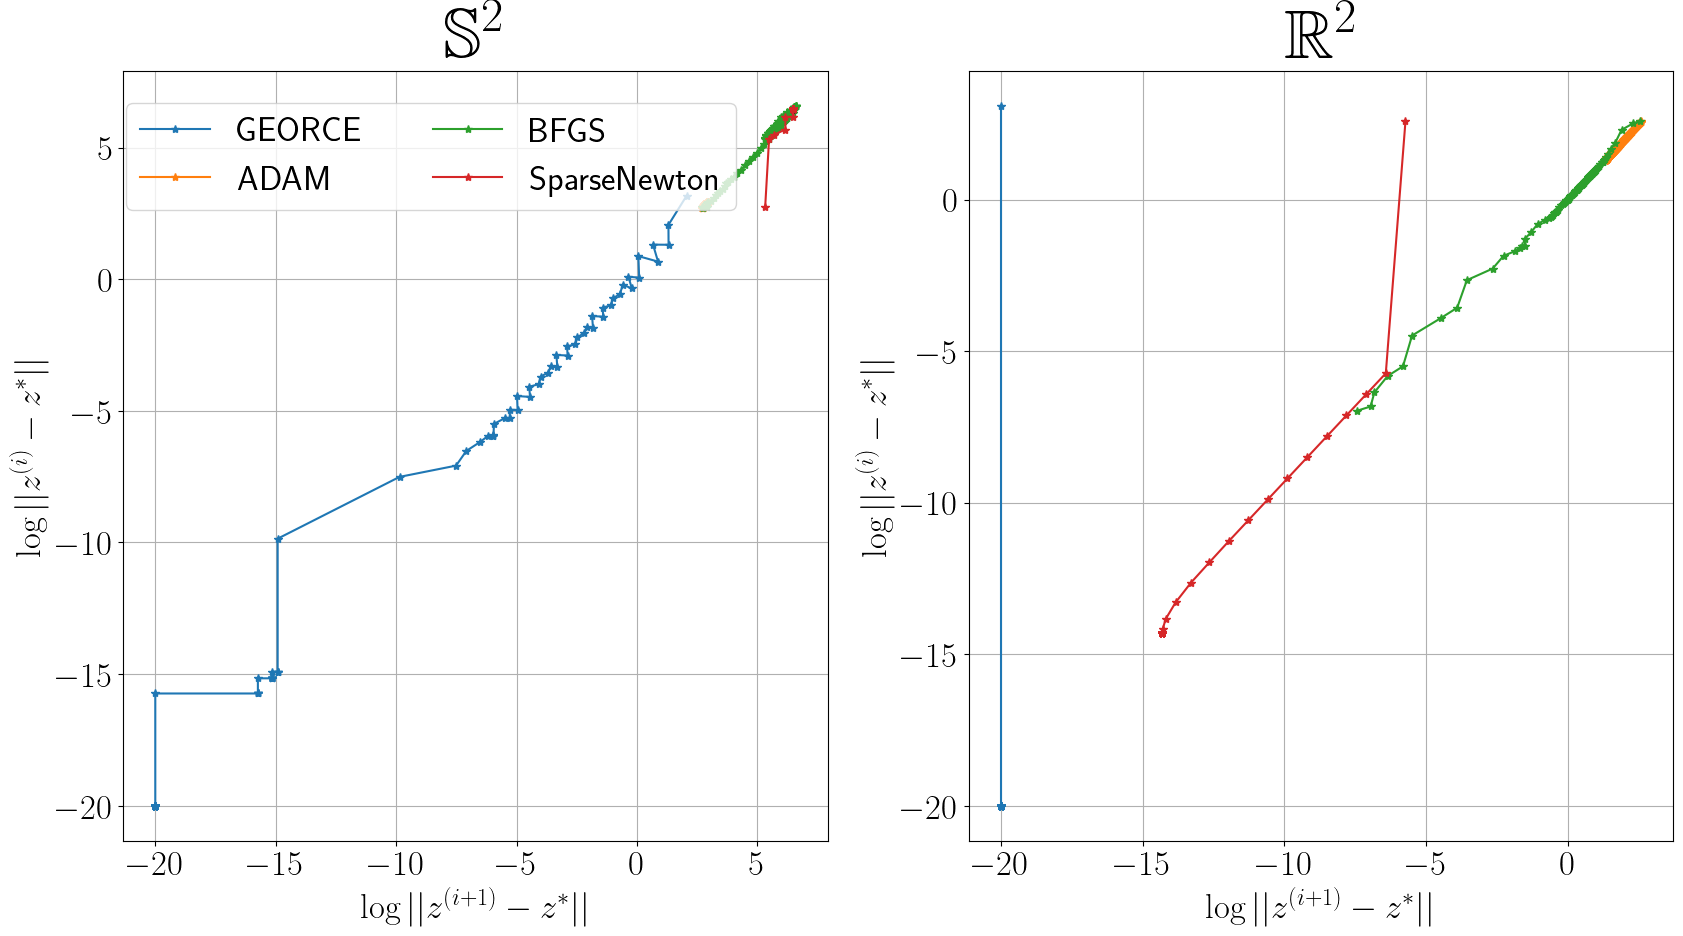

In [59]:
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(121)

for curve_name in sphere_methods.keys():
    if curve_name == "GEORCE":
        x,y = compute_convergence(sphere_methods[curve_name]['zt'], sphere_methods['GEORCE']['zt'][-1], True)
    else:
        x,y = compute_convergence(sphere_methods[curve_name]['zt'], sphere_methods['GEORCE']['zt'][-1], False)
    ax.plot(x,y, '-*')
    ax.set_title(r"$\mathbb{S}^{2}$", fontsize=50)
    ax.grid(True)
ax.set_xlabel(r"$\log ||z^{(i+1)}-z^{*}||$", fontsize=25)
ax.set_ylabel(r"$\log ||z^{(i)}-z^{*}||$", fontsize=25)

ax = fig.add_subplot(122)
for curve_name in euclidean_methods.keys():
    if curve_name == "GEORCE":
        x,y = compute_convergence(euclidean_methods[curve_name]['zt'], euclidean_methods['GEORCE']['zt'][-1], True)
    else:
        x,y = compute_convergence(euclidean_methods[curve_name]['zt'], euclidean_methods['GEORCE']['zt'][-1], False)
    ax.plot(x,y, '-*', label=curve_name)
    ax.set_title("$\mathbb{R}^{2}$", fontsize=50)
    ax.grid(True)
ax.set_xlabel(r"$\log ||z^{(i+1)}-z^{*}||$", fontsize=25)
ax.set_ylabel(r"$\log ||z^{(i)}-z^{*}||$", fontsize=25)

lines_labels = [ax.get_legend_handles_labels()]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines, labels, loc=(0.075,0.775), ncol=2, fontsize=25)

plt.show()

fig.tight_layout()

save_path = f'{figure_path}quadratic_convergence.pdf'
fig.savefig(save_path, format='pdf', pad_inches=0.1, bbox_inches='tight')

plt.show()

